# Notebook 05 — Within-Category Correlation & Basket Analysis

**Assignment**: Explorer 05 — Category cohesion family.

**Lenses**: pairwise correlation (returns + levels), cointegration (Engle-Granger), lead-lag CCF, basket spread.

**Data**: `prices_round_5_day_{2,3,4}.csv` (semicolon-separated, read-only).

**Triage rubric**: within-cat corr > 0.95 = likely exploitable basket; 0.7–0.95 = probably tradable; below = probably noise.

**10 categories**: GALAXY_SOUNDS, SLEEP_POD, MICROCHIP, PEBBLES, ROBOT, UV_VISOR, TRANSLATOR, PANEL, OXYGEN_SHAKE, SNACKPACK.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations

# ── Data loading ──────────────────────────────────────────────────────────────
DATA_DIR = '../../data/round_5/prices'
days = [2, 3, 4]
frames = []
for d in days:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_5_day_{d}.csv', sep=';')
    frames.append(df)
all_data = pd.concat(frames, ignore_index=True)

print(f'Total rows: {len(all_data):,}')
print(f'Products  : {all_data["product"].nunique()}')
print(f'Days      : {sorted(all_data["day"].unique())}')

Total rows: 1,500,000
Products  : 50
Days      : [np.int64(2), np.int64(3), np.int64(4)]


In [2]:
# ── Category map ──────────────────────────────────────────────────────────────
CATEGORIES = {
    'GALAXY_SOUNDS': ['GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_BLACK_HOLES',
                      'GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_WINDS',
                      'GALAXY_SOUNDS_SOLAR_FLAMES'],
    'SLEEP_POD':     ['SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL','SLEEP_POD_POLYESTER',
                      'SLEEP_POD_NYLON','SLEEP_POD_COTTON'],
    'MICROCHIP':     ['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_SQUARE',
                      'MICROCHIP_RECTANGLE','MICROCHIP_TRIANGLE'],
    'PEBBLES':       ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
    'ROBOT':         ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES',
                      'ROBOT_LAUNDRY','ROBOT_IRONING'],
    'UV_VISOR':      ['UV_VISOR_YELLOW','UV_VISOR_AMBER','UV_VISOR_ORANGE',
                      'UV_VISOR_RED','UV_VISOR_MAGENTA'],
    'TRANSLATOR':    ['TRANSLATOR_SPACE_GRAY','TRANSLATOR_ASTRO_BLACK',
                      'TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST',
                      'TRANSLATOR_VOID_BLUE'],
    'PANEL':         ['PANEL_1X2','PANEL_2X2','PANEL_1X4','PANEL_2X4','PANEL_4X4'],
    'OXYGEN_SHAKE':  ['OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH',
                      'OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_CHOCOLATE','OXYGEN_SHAKE_GARLIC'],
    'SNACKPACK':     ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO',
                      'SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY'],
}

# ── Build per-day pivot tables: timestamp × product (mid_price) ───────────────
def build_pivot(day_df):
    return day_df.pivot_table(index='timestamp', columns='product', values='mid_price')

pivots = {}
for d in days:
    pivots[d] = build_pivot(all_data[all_data['day'] == d])

# Concatenated pivot (all days, reindex to make timestamps unique per day)
full_pivot = all_data.assign(
    global_ts=lambda x: (x['day'] - 2) * 1_000_000 + x['timestamp']
).pivot_table(index='global_ts', columns='product', values='mid_price')

print('Full pivot shape:', full_pivot.shape)
print('Missing values per product (first 5):')
print(full_pivot.isnull().sum().head())

Full pivot shape: (30000, 50)
Missing values per product (first 5):
product
GALAXY_SOUNDS_BLACK_HOLES        0
GALAXY_SOUNDS_DARK_MATTER        0
GALAXY_SOUNDS_PLANETARY_RINGS    0
GALAXY_SOUNDS_SOLAR_FLAMES       0
GALAXY_SOUNDS_SOLAR_WINDS        0
dtype: int64


## Lens 1 — Pairwise Correlation: Levels and Returns

For each of the 10 categories, compute all C(5,2)=10 pairwise Pearson correlations on:
- **mid-price levels** (each day separately, then all-days)
- **tick-by-tick returns** (log mid_price differences)

Threshold: level corr > 0.95 = basket candidate; returns corr > 0.5 = co-movement signal.

In [3]:
# ── Lens 1: Pairwise correlations ─────────────────────────────────────────────

def pairwise_corr(pivot, products):
    """Return a dict of (p1,p2): corr for levels and returns."""
    sub = pivot[products].dropna(how='all')
    # forward fill up to 3 ticks to handle sparse data, then drop remaining NaN
    sub = sub.ffill(limit=3).dropna()
    returns = np.log(sub / sub.shift(1)).dropna()
    level_corr = sub.corr()
    ret_corr   = returns.corr()
    return level_corr, ret_corr, len(sub)

summary_rows = []

for cat, prods in CATEGORIES.items():
    lc_all, rc_all, n_all = pairwise_corr(full_pivot, prods)
    # Extract lower-triangle pairs
    pairs = list(combinations(prods, 2))
    for p1, p2 in pairs:
        lc = lc_all.loc[p1, p2]
        rc = rc_all.loc[p1, p2]
        summary_rows.append({
            'category': cat,
            'p1': p1.replace(cat+'_',''),
            'p2': p2.replace(cat+'_',''),
            'level_corr': round(lc, 4),
            'ret_corr':   round(rc, 4),
            'n_ticks': n_all,
        })

corr_df = pd.DataFrame(summary_rows)
print('All-days pairwise correlations (level + returns):')
print(corr_df.to_string(index=False))

All-days pairwise correlations (level + returns):
     category               p1               p2  level_corr  ret_corr  n_ticks
GALAXY_SOUNDS      DARK_MATTER      BLACK_HOLES     -0.0081    0.0001    30000
GALAXY_SOUNDS      DARK_MATTER  PLANETARY_RINGS      0.4342    0.0074    30000
GALAXY_SOUNDS      DARK_MATTER      SOLAR_WINDS     -0.0157   -0.0013    30000
GALAXY_SOUNDS      DARK_MATTER     SOLAR_FLAMES     -0.0225    0.0045    30000
GALAXY_SOUNDS      BLACK_HOLES  PLANETARY_RINGS      0.0743    0.0012    30000
GALAXY_SOUNDS      BLACK_HOLES      SOLAR_WINDS      0.4653    0.0089    30000
GALAXY_SOUNDS      BLACK_HOLES     SOLAR_FLAMES     -0.1171    0.0019    30000
GALAXY_SOUNDS  PLANETARY_RINGS      SOLAR_WINDS      0.0876    0.0002    30000
GALAXY_SOUNDS  PLANETARY_RINGS     SOLAR_FLAMES     -0.0091    0.0130    30000
GALAXY_SOUNDS      SOLAR_WINDS     SOLAR_FLAMES     -0.3352    0.0040    30000
    SLEEP_POD            SUEDE        LAMB_WOOL     -0.0605    0.0065    30000
  

In [4]:
# ── Category-level summary: min/median/max level_corr ─────────────────────────
cat_summary = corr_df.groupby('category')['level_corr'].agg(['min','median','max']).round(4)
cat_summary.columns = ['lc_min','lc_median','lc_max']
cat_ret_summary = corr_df.groupby('category')['ret_corr'].agg(['min','median','max']).round(4)
cat_ret_summary.columns = ['rc_min','rc_median','rc_max']
cat_full = pd.concat([cat_summary, cat_ret_summary], axis=1).sort_values('lc_median', ascending=False)
print('Category-level correlation summary (sorted by median level corr):')
print(cat_full.to_string())

Category-level correlation summary (sorted by median level corr):
               lc_min  lc_median  lc_max  rc_min  rc_median  rc_max
category                                                           
SLEEP_POD     -0.0605     0.3525  0.8752 -0.0076     0.0046  0.0090
GALAXY_SOUNDS -0.3352    -0.0086  0.4653 -0.0013     0.0030  0.0130
UV_VISOR      -0.8673    -0.0682  0.5844 -0.0024     0.0058  0.0196
TRANSLATOR    -0.6654    -0.0942  0.4673 -0.0047     0.0042  0.0175
PEBBLES       -0.8344    -0.2329  0.7983 -0.5059    -0.0002  0.0156
MICROCHIP     -0.8823    -0.2546  0.8705  0.0018     0.0058  0.0126
PANEL         -0.6041    -0.2680  0.6443 -0.0083     0.0057  0.0108
OXYGEN_SHAKE  -0.5579    -0.2760  0.6458  0.0028     0.0068  0.0134
SNACKPACK     -0.9259    -0.3634  0.4704 -0.9232     0.0208  0.9126
ROBOT         -0.8152    -0.6674  0.7874 -0.0096    -0.0008  0.0138


In [5]:
# ── Per-day level-corr stability check ────────────────────────────────────────
day_corr_rows = []
for d in days:
    for cat, prods in CATEGORIES.items():
        lc, rc, n = pairwise_corr(pivots[d], prods)
        pairs = list(combinations(prods, 2))
        for p1, p2 in pairs:
            day_corr_rows.append({
                'day': d, 'category': cat,
                'pair': f"{p1.replace(cat+'_','')}/{p2.replace(cat+'_','')}",
                'level_corr': round(lc.loc[p1,p2], 4),
                'ret_corr':   round(rc.loc[p1,p2], 4),
            })

day_corr_df = pd.DataFrame(day_corr_rows)

# Stability: std of level_corr across days per pair
pair_stability = day_corr_df.groupby(['category','pair'])['level_corr'].agg(['mean','std']).round(4)
pair_stability.columns = ['mean_lc','std_lc']
pair_stability = pair_stability.sort_values('mean_lc', ascending=False)
print('Top 20 pairs by mean level-corr across days 2/3/4:')
print(pair_stability.head(20).to_string())

Top 20 pairs by mean level-corr across days 2/3/4:
                                           mean_lc  std_lc
category      pair                                        
SLEEP_POD     POLYESTER/COTTON              0.7404  0.1108
TRANSLATOR    SPACE_GRAY/GRAPHITE_MIST      0.5600  0.3015
PEBBLES       XS/S                          0.5168  0.3613
MICROCHIP     CIRCLE/RECTANGLE              0.4565  0.1928
SLEEP_POD     SUEDE/COTTON                  0.4457  0.1926
              LAMB_WOOL/NYLON               0.4277  0.1725
              SUEDE/POLYESTER               0.4251  0.1734
ROBOT         VACUUMING/LAUNDRY             0.3924  0.3115
SNACKPACK     PISTACHIO/STRAWBERRY          0.3903  0.4048
PANEL         2X2/1X4                       0.3700  0.3080
MICROCHIP     OVAL/TRIANGLE                 0.3601  0.4995
TRANSLATOR    ASTRO_BLACK/GRAPHITE_MIST     0.3221  0.4613
UV_VISOR      YELLOW/MAGENTA                0.3089  0.4172
OXYGEN_SHAKE  CHOCOLATE/GARLIC              0.2812  0.8033
PANEL

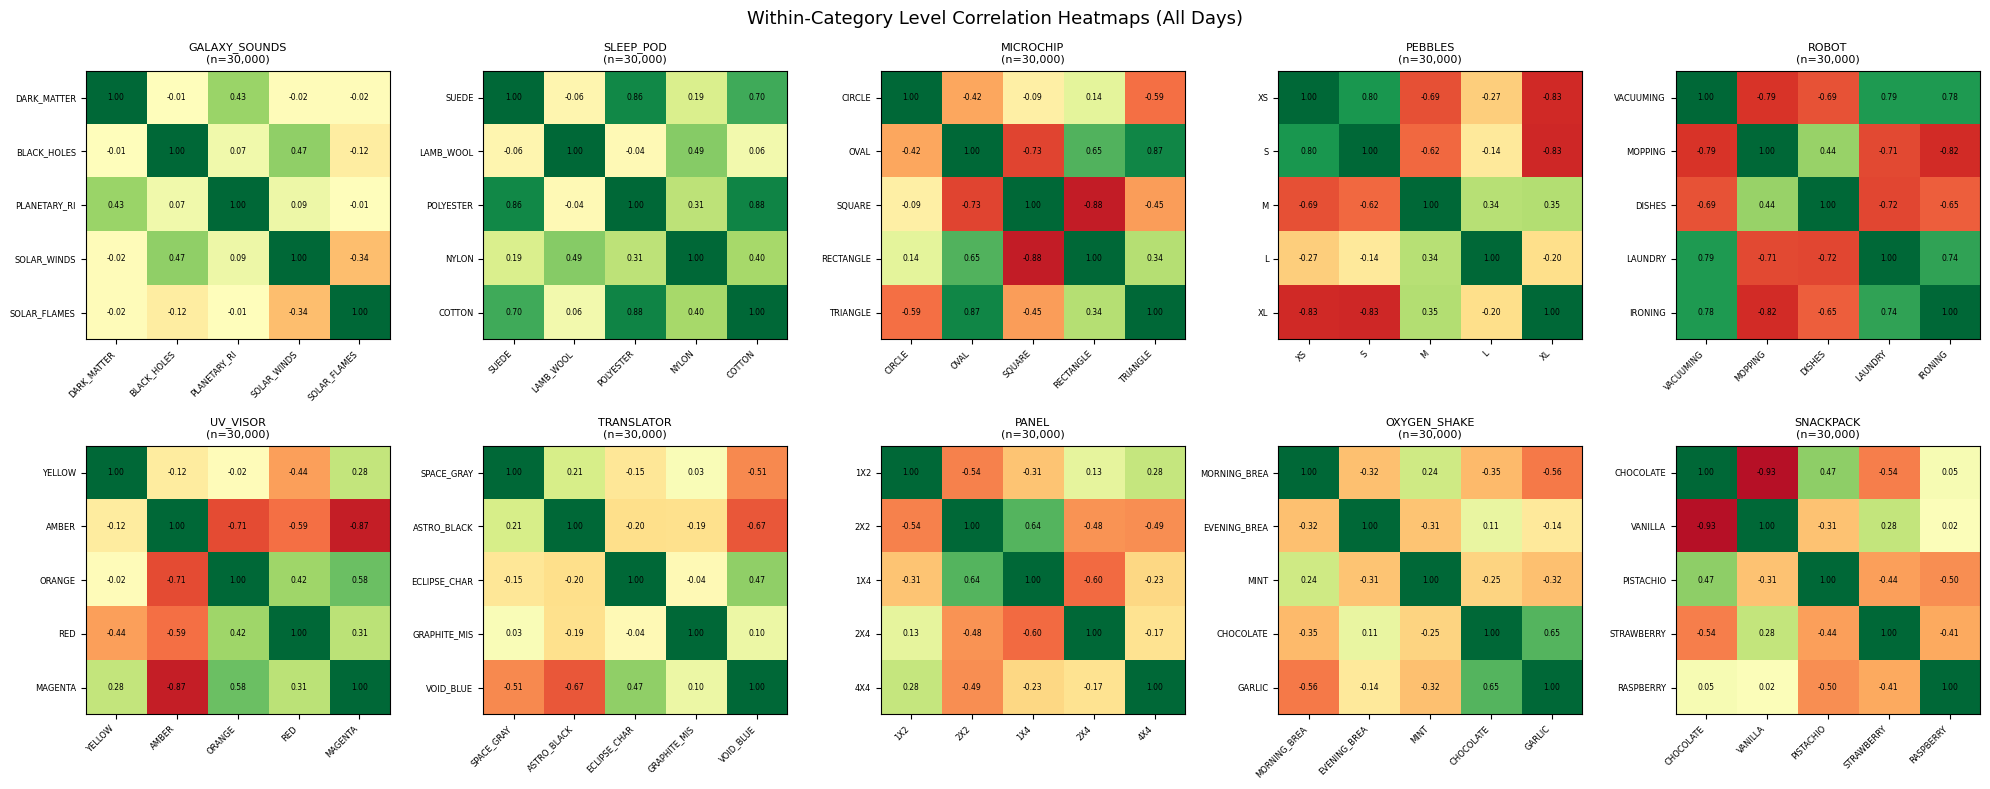

Saved: plots/05_level_corr_heatmaps.png


In [6]:
# ── Plot 1: Level-corr heatmaps per category ───────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

import matplotlib.colors as mcolors

for idx, (cat, prods) in enumerate(CATEGORIES.items()):
    lc, _, n = pairwise_corr(full_pivot, prods)
    short_names = [p.replace(cat+'_','')[:12] for p in prods]
    lc.index = short_names
    lc.columns = short_names
    ax = axes[idx]
    im = ax.imshow(lc.values, vmin=-1, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(short_names, fontsize=6)
    ax.set_title(f'{cat}\n(n={n:,})', fontsize=8)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{lc.values[i,j]:.2f}', ha='center', va='center',
                    fontsize=5.5, color='black')

fig.suptitle('Within-Category Level Correlation Heatmaps (All Days)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/05_level_corr_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/05_level_corr_heatmaps.png')

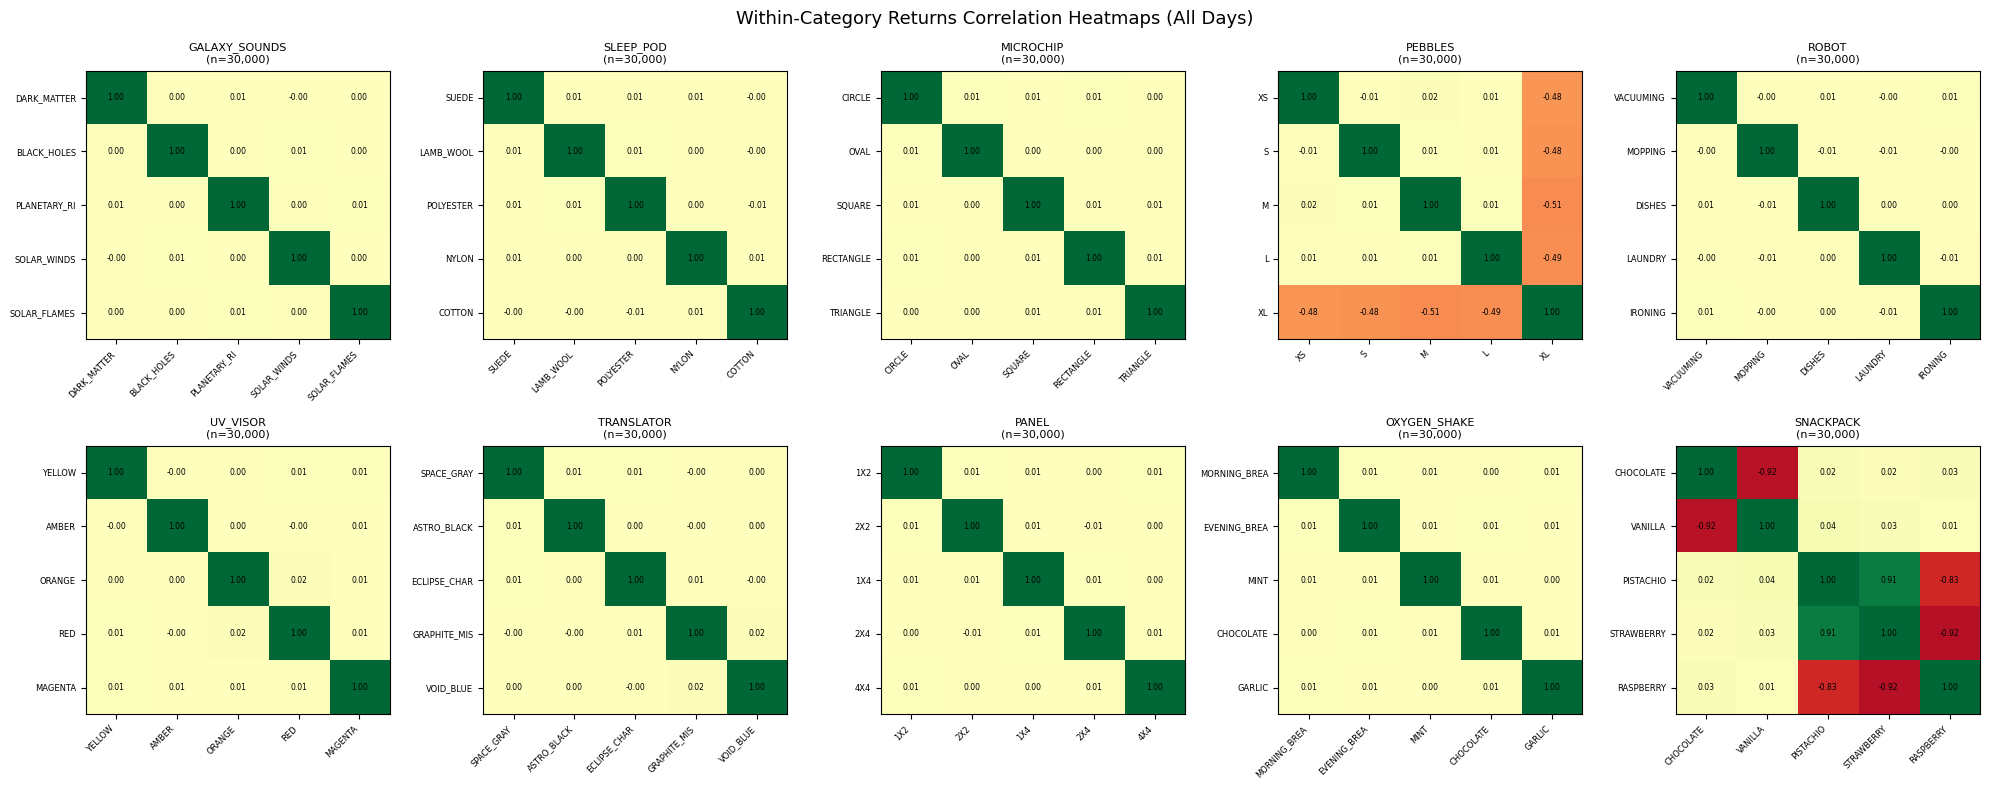

Saved: plots/05_returns_corr_heatmaps.png


In [7]:
# ── Plot 2: Returns-corr heatmaps per category ────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (cat, prods) in enumerate(CATEGORIES.items()):
    _, rc, n = pairwise_corr(full_pivot, prods)
    short_names = [p.replace(cat+'_','')[:12] for p in prods]
    rc.index = short_names
    rc.columns = short_names
    ax = axes[idx]
    im = ax.imshow(rc.values, vmin=-1, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(short_names, fontsize=6)
    ax.set_title(f'{cat}\n(n={n:,})', fontsize=8)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{rc.values[i,j]:.2f}', ha='center', va='center',
                    fontsize=5.5, color='black')

fig.suptitle('Within-Category Returns Correlation Heatmaps (All Days)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/05_returns_corr_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/05_returns_corr_heatmaps.png')

## Lens 2 — Cointegration (Engle-Granger)

For each category, test all C(5,2)=10 pairs for cointegration using `statsmodels.tsa.stattools.coint`.
Report p-value and cointegrating coefficient. Threshold: p < 0.05 = cointegrated.

In [8]:
# ── Lens 2: Engle-Granger cointegration ───────────────────────────────────────
coint_rows = []

for cat, prods in CATEGORIES.items():
    sub = full_pivot[prods].ffill(limit=3).dropna()
    pairs = list(combinations(prods, 2))
    for p1, p2 in pairs:
        s1 = sub[p1].values
        s2 = sub[p2].values
        try:
            t_stat, p_val, crit_vals = coint(s1, s2)
        except Exception as e:
            p_val = np.nan
            t_stat = np.nan
        coint_rows.append({
            'category': cat,
            'p1': p1.replace(cat+'_',''),
            'p2': p2.replace(cat+'_',''),
            'coint_pval': round(float(p_val), 4) if not np.isnan(p_val) else np.nan,
            'coint_tstat': round(float(t_stat), 4) if not np.isnan(t_stat) else np.nan,
            'cointegrated': p_val < 0.05 if not np.isnan(p_val) else False,
        })

coint_df = pd.DataFrame(coint_rows)
print('Cointegrated pairs (p < 0.05):')
print(coint_df[coint_df['cointegrated']].to_string(index=False))
print(f'\nTotal cointegrated pairs: {coint_df["cointegrated"].sum()} / {len(coint_df)}')

Cointegrated pairs (p < 0.05):
 category        p1         p2  coint_pval  coint_tstat  cointegrated
MICROCHIP    SQUARE  RECTANGLE      0.0274      -3.5602          True
SNACKPACK CHOCOLATE  PISTACHIO      0.0453      -3.3745          True
SNACKPACK CHOCOLATE STRAWBERRY      0.0356      -3.4652          True
SNACKPACK PISTACHIO STRAWBERRY      0.0313      -3.5120          True

Total cointegrated pairs: 4 / 100


In [9]:
# ── Cointegration summary per category ────────────────────────────────────────
coint_cat_summary = coint_df.groupby('category').agg(
    n_pairs=('cointegrated', 'count'),
    n_coint=('cointegrated', 'sum'),
    min_pval=('coint_pval', 'min'),
    median_pval=('coint_pval', 'median'),
).sort_values('n_coint', ascending=False)
print('Cointegration summary per category:')
print(coint_cat_summary.to_string())

Cointegration summary per category:
               n_pairs  n_coint  min_pval  median_pval
category                                              
SNACKPACK           10        3    0.0313      0.09680
MICROCHIP           10        1    0.0274      0.56475
GALAXY_SOUNDS       10        0    0.1149      0.64130
OXYGEN_SHAKE        10        0    0.0978      0.62395
PANEL               10        0    0.3113      0.66450
PEBBLES             10        0    0.1943      0.44130
ROBOT               10        0    0.0701      0.25015
SLEEP_POD           10        0    0.0753      0.35720
TRANSLATOR          10        0    0.1249      0.61630
UV_VISOR            10        0    0.0776      0.78155


In [10]:
# ── Per-day cointegration stability ───────────────────────────────────────────
day_coint_rows = []
for d in days:
    for cat, prods in CATEGORIES.items():
        sub = pivots[d][prods].ffill(limit=3).dropna()
        pairs = list(combinations(prods, 2))
        for p1, p2 in pairs:
            s1 = sub[p1].values
            s2 = sub[p2].values
            try:
                _, p_val, _ = coint(s1, s2)
            except:
                p_val = np.nan
            day_coint_rows.append({
                'day': d, 'category': cat,
                'pair': f"{p1.replace(cat+'_','')}/{p2.replace(cat+'_','')}",
                'coint_pval': round(float(p_val), 4) if not np.isnan(p_val) else np.nan,
                'cointegrated': p_val < 0.05 if not np.isnan(p_val) else False,
            })

day_coint_df = pd.DataFrame(day_coint_rows)

# Pairs cointegrated on all 3 days
stable_coint = day_coint_df.groupby(['category','pair'])['cointegrated'].sum()
print('Pairs cointegrated on ALL 3 days:')
print(stable_coint[stable_coint == 3].to_string())

Pairs cointegrated on ALL 3 days:
Series([], )


## Lens 3 — Lead-Lag Cross-Correlation (CCF)

For each pair in each category, compute CCF of returns at lags -10..+10 ticks.
Look for asymmetric peaks (one product consistently leads the other).

In [11]:
# ── Lens 3: Lead-lag CCF ──────────────────────────────────────────────────────
MAX_LAG = 10

def compute_ccf(x, y, max_lag=MAX_LAG):
    """Pearson corr at lags -max_lag..+max_lag. Positive lag = x leads y."""
    n = len(x)
    lags = range(-max_lag, max_lag+1)
    results = {}
    for lag in lags:
        if lag > 0:
            r = np.corrcoef(x[:-lag], y[lag:])[0,1]
        elif lag < 0:
            r = np.corrcoef(x[-lag:], y[:lag])[0,1]
        else:
            r = np.corrcoef(x, y)[0,1]
        results[lag] = r
    return results

ccf_rows = []
# Use all-days returns
rets = np.log(full_pivot / full_pivot.shift(1)).dropna()

for cat, prods in CATEGORIES.items():
    sub_rets = rets[prods].dropna()
    pairs = list(combinations(prods, 2))
    for p1, p2 in pairs:
        x = sub_rets[p1].values
        y = sub_rets[p2].values
        ccf = compute_ccf(x, y)
        lag0 = ccf[0]
        # peak lag (max |corr| excluding lag 0)
        non_zero = {k:v for k,v in ccf.items() if k != 0}
        peak_lag = max(non_zero, key=lambda k: abs(non_zero[k]))
        peak_val = non_zero[peak_lag]
        # asymmetry: max corr at positive lags vs negative lags
        max_pos = max((abs(ccf[l]) for l in range(1, MAX_LAG+1)), default=0)
        max_neg = max((abs(ccf[l]) for l in range(-MAX_LAG, 0)), default=0)
        asymmetry = round(max_pos - max_neg, 4)  # positive = p1 leads p2
        ccf_rows.append({
            'category': cat,
            'p1': p1.replace(cat+'_',''),
            'p2': p2.replace(cat+'_',''),
            'lag0_corr': round(lag0, 4),
            'peak_lag': peak_lag,
            'peak_val': round(peak_val, 4),
            'asymmetry': asymmetry,
        })

ccf_df = pd.DataFrame(ccf_rows)
print('Top 20 pairs by |peak_val| (strongest lead-lag off-zero CCF):')
print(ccf_df.reindex(ccf_df['peak_val'].abs().sort_values(ascending=False).index).head(20).to_string(index=False))

Top 20 pairs by |peak_val| (strongest lead-lag off-zero CCF):
     category              p1               p2  lag0_corr  peak_lag  peak_val  asymmetry
        PANEL             1X2              2X4     0.0046       -10    0.0234    -0.0118
   TRANSLATOR      SPACE_GRAY ECLIPSE_CHARCOAL     0.0102        -1   -0.0221    -0.0114
    SNACKPACK         VANILLA        PISTACHIO     0.0400         1   -0.0210     0.0024
    MICROCHIP          CIRCLE             OVAL     0.0126         5    0.0206     0.0097
 OXYGEN_SHAKE  MORNING_BREATH   EVENING_BREATH     0.0090        -5   -0.0191    -0.0037
    SNACKPACK       PISTACHIO       STRAWBERRY     0.9126        -1   -0.0189    -0.0029
    SNACKPACK         VANILLA       STRAWBERRY     0.0307         1   -0.0188     0.0039
        ROBOT       VACUUMING          MOPPING    -0.0039         3   -0.0184     0.0088
      PEBBLES               M               XL    -0.5059         5   -0.0177     0.0045
GALAXY_SOUNDS PLANETARY_RINGS     SOLAR_FLAMES  

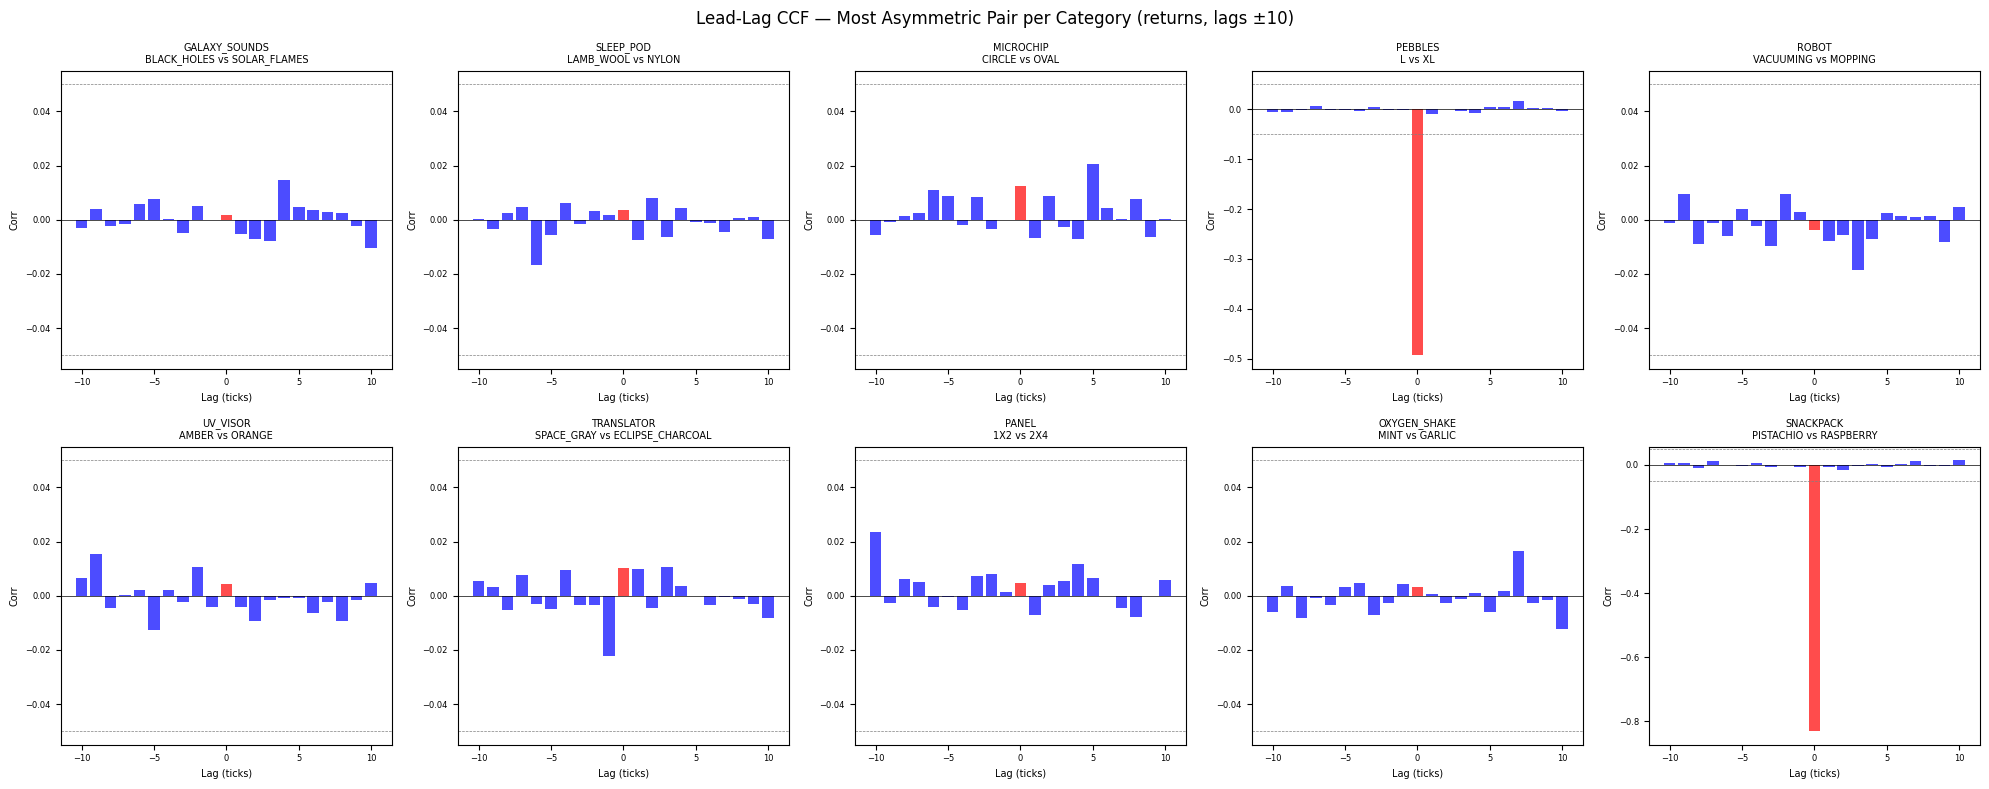

Saved: plots/05_ccf_per_category.png


In [12]:
# ── Plot 3: CCF for top pairs in each category ────────────────────────────────
# For each category, plot the CCF of the pair with the highest |asymmetry|
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (cat, prods) in enumerate(CATEGORIES.items()):
    cat_ccf = ccf_df[ccf_df['category'] == cat]
    top = cat_ccf.reindex(cat_ccf['asymmetry'].abs().sort_values(ascending=False).index).iloc[0]
    p1_full = cat + '_' + top['p1']
    p2_full = cat + '_' + top['p2']
    sub_rets = rets[[p1_full, p2_full]].dropna()
    ccf = compute_ccf(sub_rets[p1_full].values, sub_rets[p2_full].values)
    lags = list(ccf.keys())
    vals = list(ccf.values())
    ax = axes[idx]
    ax.bar(lags, vals, color=['blue' if l != 0 else 'red' for l in lags], alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(0.05, color='gray', linestyle='--', linewidth=0.5)
    ax.axhline(-0.05, color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(f'{cat}\n{top["p1"]} vs {top["p2"]}', fontsize=7)
    ax.set_xlabel('Lag (ticks)', fontsize=7)
    ax.set_ylabel('Corr', fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle('Lead-Lag CCF — Most Asymmetric Pair per Category (returns, lags ±10)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/05_ccf_per_category.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/05_ccf_per_category.png')

## Lens 4 — Basket Spread Analysis

For each category, construct an equal-weight basket (mean of 5 products). Compute the spread of each product relative to the basket.
- Spread mean (level bias): is one product consistently above/below basket?
- Spread std / mean-reversion: ADF on the spread to test stationarity.
- Spread range: how many ticks to cross one std?

In [13]:
# ── Lens 4: Basket spread ─────────────────────────────────────────────────────
basket_rows = []

for cat, prods in CATEGORIES.items():
    sub = full_pivot[prods].ffill(limit=3).dropna()
    basket = sub.mean(axis=1)
    for prod in prods:
        spread = sub[prod] - basket
        adf_result = adfuller(spread, maxlag=5, autolag='AIC')
        adf_pval = adf_result[1]
        basket_rows.append({
            'category': cat,
            'product': prod.replace(cat+'_',''),
            'spread_mean': round(spread.mean(), 4),
            'spread_std': round(spread.std(), 4),
            'spread_min': round(spread.min(), 4),
            'spread_max': round(spread.max(), 4),
            'adf_pval': round(adf_pval, 4),
            'spread_stationary': adf_pval < 0.05,
        })

basket_df = pd.DataFrame(basket_rows)
print('Basket spread statistics (all days):')
print(basket_df.to_string(index=False))

Basket spread statistics (all days):
     category          product  spread_mean  spread_std  spread_min  spread_max  adf_pval  spread_stationary
GALAXY_SOUNDS      DARK_MATTER    -571.4027    365.1887     -1436.9       114.6    0.1202              False
GALAXY_SOUNDS      BLACK_HOLES     668.8075    749.8637      -480.1      2945.3    0.9637              False
GALAXY_SOUNDS  PLANETARY_RINGS     -31.3914    617.3196     -1320.3      1155.3    0.8579              False
GALAXY_SOUNDS      SOLAR_WINDS    -360.5206    454.5924     -1446.5       576.3    0.3601              False
GALAXY_SOUNDS     SOLAR_FLAMES     294.5072    534.1303      -595.5      1507.4    0.5093              False
    SLEEP_POD            SUEDE     376.7185    509.5812      -715.0      1443.2    0.3899              False
    SLEEP_POD        LAMB_WOOL    -319.2602    626.7680     -1535.6      1557.7    0.6022              False
    SLEEP_POD        POLYESTER     819.8590    488.0203      -443.1      1715.9    0.2011  

In [14]:
# ── Basket summary per category ────────────────────────────────────────────────
basket_cat = basket_df.groupby('category').agg(
    n_stationary=('spread_stationary','sum'),
    mean_spread_std=('spread_std','mean'),
    max_spread_range=('spread_max','max'),  # largest positive deviation
).sort_values('n_stationary', ascending=False)
print('Basket spread summary per category (n_stationary out of 5 products):')
print(basket_cat.to_string())

Basket spread summary per category (n_stationary out of 5 products):
               n_stationary  mean_spread_std  max_spread_range
category                                                      
SNACKPACK                 2        221.03766            1291.4
GALAXY_SOUNDS             0        544.21894            2945.3
MICROCHIP                 0       1055.15314            6666.0
OXYGEN_SHAKE              0        585.30852            3472.1
PANEL                     0        620.08776            2938.2
PEBBLES                   0       1073.90464            7240.0
ROBOT                     0        617.14170            2744.4
SLEEP_POD                 0        516.34698            1715.9
TRANSLATOR                0        454.43240            1923.9
UV_VISOR                  0        654.75198            2242.5


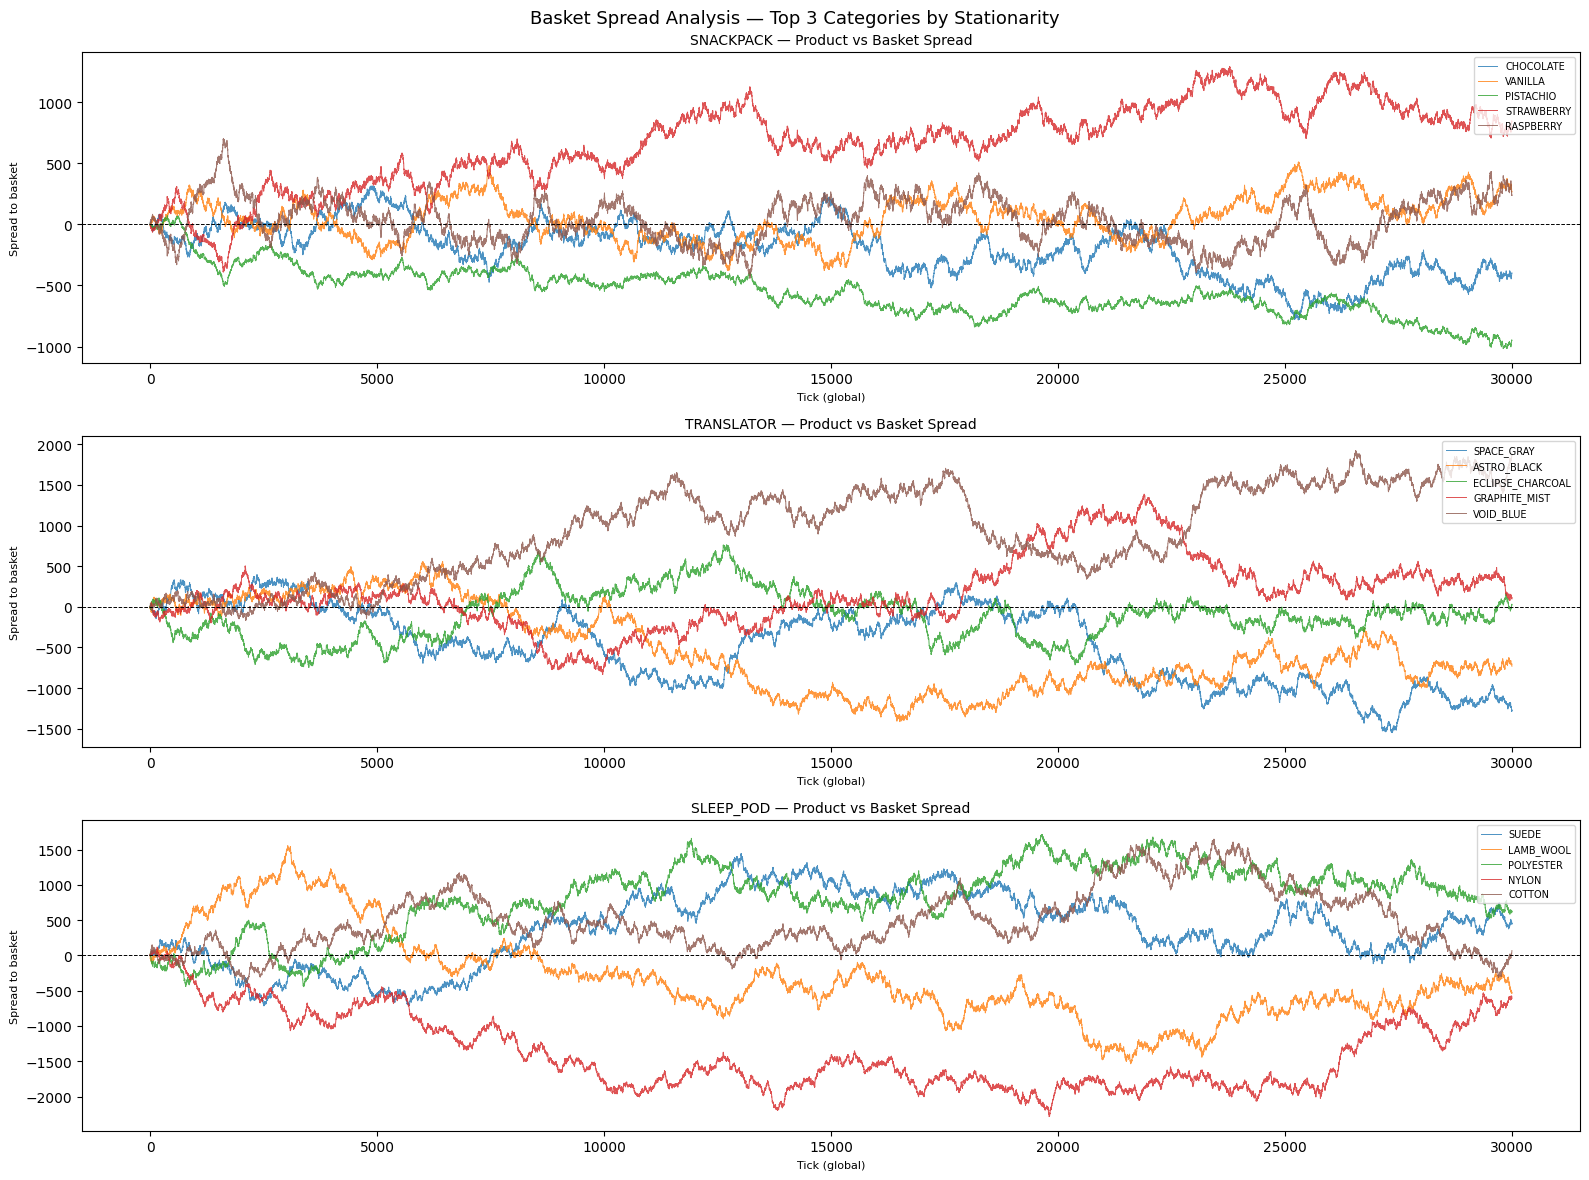

Saved: plots/05_basket_spread_top3.png


In [15]:
# ── Plot 4: Basket spread time-series for top 3 categories ────────────────────
# Pick top 3 categories by n_stationary, then by lowest median ADF pval
top_cats_for_spread = basket_cat.sort_values(['n_stationary','mean_spread_std'],
                                              ascending=[False, True]).head(3).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
colors5 = plt.cm.tab10(np.linspace(0, 0.5, 5))

for ax, cat in zip(axes, top_cats_for_spread):
    prods = CATEGORIES[cat]
    sub = full_pivot[prods].ffill(limit=3).dropna()
    basket = sub.mean(axis=1)
    for i, prod in enumerate(prods):
        spread = sub[prod] - basket
        ax.plot(spread.values, alpha=0.8, linewidth=0.7,
                label=prod.replace(cat+'_',''), color=colors5[i])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(f'{cat} — Product vs Basket Spread', fontsize=10)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('Tick (global)', fontsize=8)
    ax.set_ylabel('Spread to basket', fontsize=8)

fig.suptitle('Basket Spread Analysis — Top 3 Categories by Stationarity', fontsize=13)
plt.tight_layout()
plt.savefig('plots/05_basket_spread_top3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/05_basket_spread_top3.png')

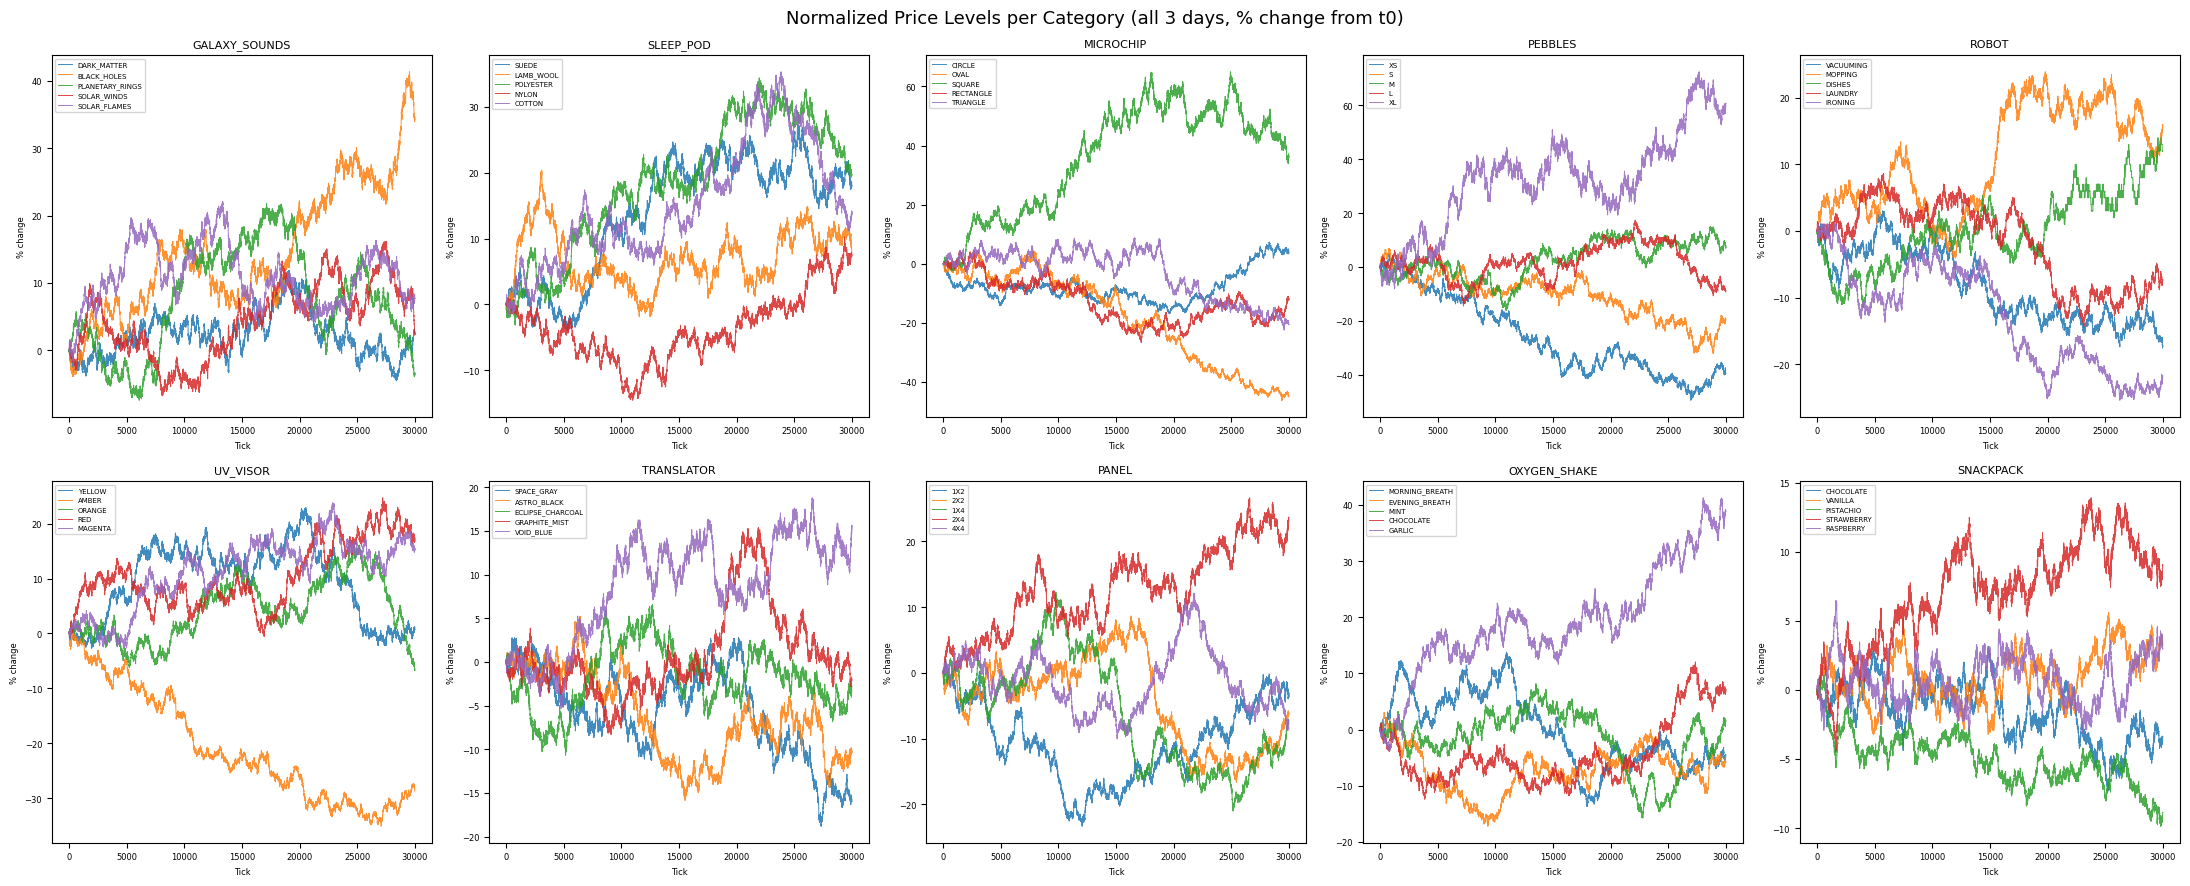

Saved: plots/05_price_levels_normalized.png


In [16]:
# ── Plot 5: Price levels for all 10 categories (normalized) ───────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, (cat, prods) in enumerate(CATEGORIES.items()):
    sub = full_pivot[prods].ffill(limit=3).dropna()
    normed = (sub - sub.iloc[0]) / sub.iloc[0] * 100  # % change from start
    ax = axes[idx]
    for prod in prods:
        ax.plot(normed[prod].values, linewidth=0.7, alpha=0.85,
                label=prod.replace(cat+'_',''))
    ax.set_title(cat, fontsize=8)
    ax.legend(fontsize=5, loc='upper left')
    ax.set_xlabel('Tick', fontsize=6)
    ax.set_ylabel('% change', fontsize=6)
    ax.tick_params(labelsize=6)

fig.suptitle('Normalized Price Levels per Category (all 3 days, % change from t0)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/05_price_levels_normalized.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/05_price_levels_normalized.png')

## Summary Table: Per-Category Triage

Combine all four lenses into a per-category triage signal.

In [17]:
# ── Final summary table ───────────────────────────────────────────────────────
summary_table = []

for cat in CATEGORIES:
    # Lens 1: level corr
    lc_med = corr_df[corr_df['category']==cat]['level_corr'].median()
    lc_min = corr_df[corr_df['category']==cat]['level_corr'].min()
    rc_med = corr_df[corr_df['category']==cat]['ret_corr'].median()

    # Lens 2: cointegration
    n_coint = coint_df[coint_df['category']==cat]['cointegrated'].sum()
    n_stable_coint = stable_coint.get((cat,), 0)  # might not exist
    # stable across all 3 days
    cat_stable = stable_coint[
        stable_coint.index.get_level_values('category') == cat
    ]
    n_stable_coint_3 = int((cat_stable == 3).sum())

    # Lens 4: basket spread stationarity
    n_stat = basket_df[basket_df['category']==cat]['spread_stationary'].sum()

    # Triage call per rubric
    if lc_med > 0.95 and n_coint >= 5:
        triage = 'likely exploitable'
    elif lc_med > 0.7 or (n_coint >= 3 and n_stat >= 3):
        triage = 'probably tradable'
    else:
        triage = 'probably noise'

    summary_table.append({
        'category': cat,
        'lc_median': round(lc_med, 4),
        'lc_min': round(lc_min, 4),
        'rc_median': round(rc_med, 4),
        'n_coint_alldays': int(n_coint),
        'n_stable_3days': n_stable_coint_3,
        'n_spread_stationary': int(n_stat),
        'triage_05': triage,
    })

summary_tbl = pd.DataFrame(summary_table).sort_values('lc_median', ascending=False)
print('=== FINAL TRIAGE TABLE (Notebook 05) ===')
print(summary_tbl.to_string(index=False))

=== FINAL TRIAGE TABLE (Notebook 05) ===
     category  lc_median  lc_min  rc_median  n_coint_alldays  n_stable_3days  n_spread_stationary      triage_05
    SLEEP_POD     0.3525 -0.0605     0.0046                0               0                    0 probably noise
GALAXY_SOUNDS    -0.0086 -0.3352     0.0030                0               0                    0 probably noise
     UV_VISOR    -0.0682 -0.8673     0.0058                0               0                    0 probably noise
   TRANSLATOR    -0.0942 -0.6654     0.0042                0               0                    0 probably noise
      PEBBLES    -0.2329 -0.8344    -0.0002                0               0                    0 probably noise
    MICROCHIP    -0.2546 -0.8823     0.0058                1               0                    0 probably noise
        PANEL    -0.2680 -0.6041     0.0057                0               0                    0 probably noise
 OXYGEN_SHAKE    -0.2760 -0.5579     0.0068            

In [18]:
# ── Cross-day level-corr stability check (for triangulation) ─────────────────
print('Per-day level-corr medians per category:')
day_stability = day_corr_df.groupby(['day','category'])['level_corr'].median().unstack('day').round(4)
day_stability.columns = [f'day{d}' for d in day_stability.columns]
day_stability['range'] = (day_stability.max(axis=1) - day_stability.min(axis=1)).round(4)
day_stability = day_stability.sort_values('range', ascending=True)
print(day_stability.to_string())
print('\n(Lower range = more stable across days = higher confidence)')

Per-day level-corr medians per category:
                 day2    day3    day4   range
category                                     
SNACKPACK     -0.1662 -0.1174 -0.0941  0.0721
GALAXY_SOUNDS -0.0752 -0.1056 -0.2357  0.1605
UV_VISOR      -0.1972 -0.1470  0.0179  0.2151
OXYGEN_SHAKE  -0.0009 -0.1632 -0.2427  0.2418
PANEL          0.0912 -0.2001  0.0778  0.2913
ROBOT         -0.0488  0.2065 -0.1294  0.3359
MICROCHIP     -0.0046  0.1839 -0.1538  0.3377
PEBBLES        0.2133 -0.2005 -0.1301  0.4138
TRANSLATOR    -0.2796 -0.2057  0.4544  0.7340
SLEEP_POD     -0.3164  0.6048 -0.1564  0.9212

(Lower range = more stable across days = higher confidence)


In [19]:
# ── Individual product spread statistics for high-signal categories ───────────
print('Basket spread ADF results for all products (sorted by ADF p-val):')
print(basket_df.sort_values('adf_pval').to_string(index=False))

Basket spread ADF results for all products (sorted by ADF p-val):
     category          product  spread_mean  spread_std  spread_min  spread_max  adf_pval  spread_stationary
    SNACKPACK        RASPBERRY      33.6243    185.4562      -441.5       702.6    0.0010               True
    SNACKPACK          VANILLA      53.1147    174.2811      -378.6       510.1    0.0275               True
    SNACKPACK        CHOCOLATE    -200.8161    216.7224      -783.0       313.7    0.0968              False
   TRANSLATOR ECLIPSE_CHARCOAL    -101.0745    302.0461      -746.6       764.2    0.1101              False
     UV_VISOR            AMBER   -2382.4537   1075.5789     -3974.8        38.8    0.1114              False
GALAXY_SOUNDS      DARK_MATTER    -571.4027    365.1887     -1436.9       114.6    0.1202              False
    SNACKPACK       STRAWBERRY     662.4208    333.7774      -390.4      1291.4    0.1614              False
    SNACKPACK        PISTACHIO    -548.3438    194.9512     -1

In [20]:
# ── Pair-level cointegration p-values for all days ───────────────────────────
print('All cointegrated pairs (p<0.05, all days combined), with per-day check:')
sig_pairs = coint_df[coint_df['cointegrated']].copy()
print(sig_pairs[['category','p1','p2','coint_pval','coint_tstat']].sort_values('coint_pval').to_string(index=False))

All cointegrated pairs (p<0.05, all days combined), with per-day check:
 category        p1         p2  coint_pval  coint_tstat
MICROCHIP    SQUARE  RECTANGLE      0.0274      -3.5602
SNACKPACK PISTACHIO STRAWBERRY      0.0313      -3.5120
SNACKPACK CHOCOLATE STRAWBERRY      0.0356      -3.4652
SNACKPACK CHOCOLATE  PISTACHIO      0.0453      -3.3745
